In [1]:
import gym
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
from gym.wrappers import RecordVideo
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

## PPO model

In [2]:
class PPO(nn.Module):
    def __init__(self, hidden_size=256, lr=0.0005, gamma=0.99, lmbda=0.95, eps_clip=0.1, K_epoch=3):
        super(PPO, self).__init__()

        self.gamma = gamma
        self.lmbda = lmbda
        self.eps_clip = eps_clip
        self.K_epoch = K_epoch

        self.data = []

        self.fc1 = nn.Linear(4, hidden_size)
        self.fc_pi = nn.Linear(hidden_size, 2)
        self.fc_v = nn.Linear(hidden_size, 1)
        self.optimizer = optim.Adam(self.parameters(), lr=lr)

    def put_data(self, transition):
        self.data.append(transition)
        
    def pi(self, x, softmax_dim=0):
        x = torch.relu(self.fc1(x))
        x = self.fc_pi(x)
        prob = torch.softmax(x, dim=softmax_dim)
        return prob

    def v(self, x):
        x = torch.relu(self.fc1(x))
        v = self.fc_v(x)
        return v
    
    def select_action(self, state):
        state = torch.tensor(state, dtype=torch.float)
        action_probs = self.pi(state.unsqueeze(0), softmax_dim=1)
        action_probs = action_probs.squeeze()
        distrib = Categorical(action_probs)
        action = distrib.sample().item()
        return action, action_probs.detach()

    def train_net(self):
        s, a, r, s_prime, prob_a, done = zip(*self.data)
        s = torch.tensor(s, dtype=torch.float)
        a = torch.tensor(a, dtype=torch.int64).unsqueeze(-1)
        r = torch.tensor(r, dtype=torch.float).unsqueeze(-1)
        s_prime = torch.tensor(s_prime, dtype=torch.float)
        prob_a = torch.tensor(prob_a, dtype=torch.float).unsqueeze(-1)
        done = torch.tensor(done, dtype=torch.float).unsqueeze(-1)
    
        for i in range(self.K_epoch):
            td_target = r + self.gamma * self.v(s_prime) * (1 - done)
            delta = td_target - self.v(s)
            delta = delta.detach().numpy()

            advantage_lst = []
            advantage = 0.0
            for reward in delta[::-1]:
                advantage = self.gamma * self.lmbda * advantage + reward
                advantage_lst.append([advantage])
            advantage_lst.reverse()
            advantage = torch.tensor(advantage_lst, dtype=torch.float)

            pi = self.pi(s, softmax_dim=1)
            pi_a = pi.gather(1, a)
            ratio = torch.exp(torch.log(pi_a) - torch.log(prob_a))

            surr1 = ratio * advantage
            surr2 = torch.clamp(ratio, 1 - self.eps_clip, 1 + self.eps_clip) * advantage
            loss = -torch.min(surr1, surr2) + nn.functional.mse_loss(self.v(s), td_target.detach())

            self.optimizer.zero_grad()
            loss.mean().backward()
            
            torch.nn.utils.clip_grad_norm_(self.parameters(), max_norm=0.5)
            self.optimizer.step()
            
        self.data = []

## A2C model

In [3]:
class A2C(nn.Module):
    def __init__(self, gamma=0.99, lmbda=0.95, hidden_size=256, lr=0.001):
        super(A2C, self).__init__()

        self.gamma = gamma
        self.lmbda = lmbda
        
        self.data = []

        self.fc1 = nn.Linear(4, hidden_size)
        self.fc_pi = nn.Linear(hidden_size, 2)
        self.fc_v = nn.Linear(hidden_size, 1)
        self.optimizer = optim.Adam(self.parameters(), lr=lr)

    def pi(self, x, softmax_dim=0):
        x = torch.relu(self.fc1(x))
        x = self.fc_pi(x)
        prob = torch.softmax(x, dim=softmax_dim)
        return prob

    def v(self, x):
        x = torch.relu(self.fc1(x))
        v = self.fc_v(x)
        return v
    
    def select_action(self, state):
        state = torch.tensor(state, dtype=torch.float)
        action_probs = self.pi(state.unsqueeze(0), softmax_dim=1)
        action_probs = action_probs.squeeze()
        distrib = Categorical(action_probs)
        action = distrib.sample().item()
        return action, action_probs.detach()

    def put_data(self, transition):
        self.data.append(transition)

    def train_net(self):
        s, a, r, s_prime, prob_a, done = zip(*self.data)
        s = torch.tensor(s, dtype=torch.float)
        a = torch.tensor(a, dtype=torch.int64).unsqueeze(-1)
        r = torch.tensor(r, dtype=torch.float).unsqueeze(-1)
        s_prime = torch.tensor(s_prime, dtype=torch.float)
        prob_a = torch.tensor(prob_a, dtype=torch.float).unsqueeze(-1)
        done = torch.tensor(done, dtype=torch.float).unsqueeze(-1)

        td_target = r + self.gamma * self.v(s_prime) * (1 - done)
        delta = td_target - self.v(s)
        delta = delta.detach().numpy()

        advantage_lst = []
        advantage = 0.0
        for delta_t in delta[::-1]:
            advantage = self.gamma * self.lmbda * advantage + delta_t[0]
            advantage_lst.append([advantage])
        advantage_lst.reverse()
        advantage = torch.tensor(advantage_lst, dtype=torch.float)

        pi = self.pi(s, softmax_dim=1)
        pi_a = pi.gather(1, a)
        loss = -torch.log(pi_a) * advantage.detach() + nn.functional.mse_loss(self.v(s), td_target.detach())

        self.optimizer.zero_grad()
        loss.mean().backward()
        self.optimizer.step()

        self.data = []

## training loop

In [4]:
def train(model, print_interval=20, max_steps=500, T_horizon=20, num_episode=500):
    env = gym.make('CartPole-v1')
    score = 0.0

    scores = []
    for episode in range(1, num_episode + 1):
        s, _ = env.reset()
        for step in range(1, max_steps + 1):
            a, prob_a = model.select_action(s)
            s_prime, r, done, info, _ = env.step(a)
            model.put_data((s, a, r, s_prime, prob_a[a].item(), done))

            s = s_prime
            score += r

            if step % T_horizon == 0 or step == max_steps or done:
                model.train_net()

            if done:
                break

        if episode % print_interval == 0 and episode != 0:
            scores.append((episode, score / print_interval))
            print("# of episode :{}, avg score : {:.1f}".format(episode, score / print_interval))
            score = 0.0

    env.close()
    return scores

In [5]:
a2c_model = A2C(hidden_size=256, gamma=0.99, lr=1e-2)

In [6]:
a2c_scores = train(a2c_model, print_interval=50, max_steps=500, T_horizon=500, num_episode=1000)

# of episode :50, avg score : 10.2
# of episode :100, avg score : 34.9
# of episode :150, avg score : 158.8
# of episode :200, avg score : 347.2
# of episode :250, avg score : 128.1
# of episode :300, avg score : 254.8
# of episode :350, avg score : 203.0
# of episode :400, avg score : 178.4
# of episode :450, avg score : 491.5
# of episode :500, avg score : 500.0
# of episode :550, avg score : 500.0
# of episode :600, avg score : 500.0
# of episode :650, avg score : 498.3
# of episode :700, avg score : 500.0
# of episode :750, avg score : 500.0
# of episode :800, avg score : 500.0
# of episode :850, avg score : 500.0
# of episode :900, avg score : 500.0
# of episode :950, avg score : 500.0
# of episode :1000, avg score : 500.0


In [7]:
ppo_model = PPO(hidden_size=256, lr=0.001, gamma=0.99, lmbda=0.95, eps_clip=0.1, K_epoch=3)

In [8]:
ppo_scores = train(ppo_model, print_interval=50, max_steps=500, T_horizon=20, num_episode=1000)

# of episode :50, avg score : 38.7
# of episode :100, avg score : 56.1
# of episode :150, avg score : 75.7
# of episode :200, avg score : 73.2
# of episode :250, avg score : 43.1
# of episode :300, avg score : 393.3
# of episode :350, avg score : 260.8
# of episode :400, avg score : 181.9
# of episode :450, avg score : 466.4
# of episode :500, avg score : 499.9
# of episode :550, avg score : 499.3
# of episode :600, avg score : 500.0
# of episode :650, avg score : 500.0
# of episode :700, avg score : 500.0
# of episode :750, avg score : 500.0
# of episode :800, avg score : 500.0
# of episode :850, avg score : 500.0
# of episode :900, avg score : 500.0
# of episode :950, avg score : 500.0
# of episode :1000, avg score : 500.0


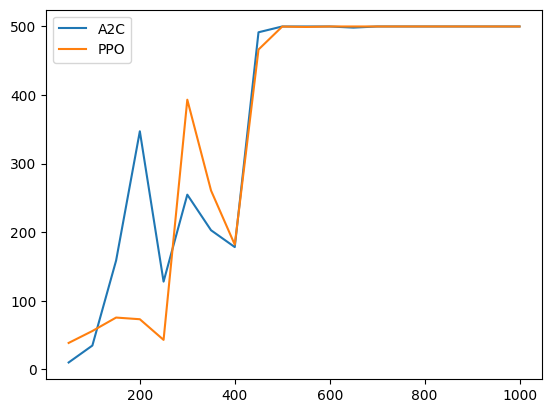

In [9]:
plt.plot([p[0] for p in a2c_scores], [p[1] for p in a2c_scores], label='A2C')
plt.plot([p[0] for p in ppo_scores], [p[1] for p in ppo_scores], label='PPO')
plt.legend(loc='best')
plt.show()

In [10]:
def evaluate(model, max_steps, file_name):
    env = gym.make('CartPole-v1', render_mode='rgb_array')
    env = RecordVideo(env, './video', name_prefix=file_name, episode_trigger=lambda x: x % 1 == 0)
    s, _ = env.reset()

    score = 0
    s, _ = env.reset()
    for step in range(1, max_steps + 1):
        a, _ = model.select_action(s)
        s_prime, r, done, info, _ = env.step(a)
        
        score += r
        s = s_prime
        
    env.close()
    print(f'score: {score}')

In [ ]:
evaluate(a2c_model, 1000, 'a2c')

In [ ]:
evaluate(ppo_model, 1000, 'ppo')